In [16]:
import os
import random
import shutil

# ===== CHANGE NOTHING HERE =====
base_dir = "/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset"

cat_src = os.path.join(base_dir, "cat")
dog_src = os.path.join(base_dir, "dog")

train_cat = os.path.join(base_dir, "train_cat")
test_cat  = os.path.join(base_dir, "test_cat")

train_dog = os.path.join(base_dir, "train_dog")
test_dog  = os.path.join(base_dir, "test_dog")

# Create folders if not exist
for d in [train_cat, test_cat, train_dog, test_dog]:
    os.makedirs(d, exist_ok=True)

# ===== FUNCTION TO SPLIT =====
def split_images(src_dir, train_dir, test_dir, split_ratio=0.8):
    images = [img for img in os.listdir(src_dir) if not img.startswith(".")]
    random.shuffle(images)

    split = int(split_ratio * len(images))

    for img in images[:split]:
        shutil.copy(os.path.join(src_dir, img), train_dir)

    for img in images[split:]:
        shutil.copy(os.path.join(src_dir, img), test_dir)

    print(f"✅ {os.path.basename(src_dir)} → Train: {len(images[:split])}, Test: {len(images[split:])}")

# ===== RUN SPLITS =====
split_images(cat_src, train_cat, test_cat)
split_images(dog_src, train_dog, test_dog)

print("🎉 Cat & Dog images split successfully!")


✅ cat → Train: 400, Test: 100
✅ dog → Train: 400, Test: 100
🎉 Cat & Dog images split successfully!


In [17]:
import os
print(os.getcwd())



/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset


In [18]:
import cv2
import os
import random
import numpy as np


In [21]:
mydir=r'/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset/dataset/train'

In [22]:
categories=['cats','dogs']


In [24]:
import os
import cv2

# Correct base directory
base_dir = "/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset/train"

categories = {
    "train_cat": 0,
    "train_dog": 1
}

data = []

for folder, label in categories.items():
    folder_path = os.path.join(base_dir, folder)

    print(f"Reading from: {folder_path}")

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (150, 150))
        data.append([img, label])

print(f"✅ Loaded {len(data)} images successfully")


Reading from: /Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset/train/train_cat
Reading from: /Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Data_Augmentation/dataset/train/train_dog
✅ Loaded 800 images successfully


In [25]:
random.shuffle(data)


In [26]:
x=[]
y=[]
for i in data:
    x.append(i[0])
    y.append(i[1])

In [27]:
y=np.array(y)
x=np.array(x)


In [28]:
x.shape

(800, 150, 150, 3)

In [29]:
y.shape

(800,)

In [30]:
x=x/255

In [31]:
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Activation,Dropout


In [32]:
model=Sequential()
model.add(Conv2D(32,(3,3),input_shape=(150,150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='rmsprop',metrics=['accuracy'])

In [36]:
normal=model.fit(x,y,epochs=5,validation_split=0.1)

Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.6625 - loss: 0.6678 - val_accuracy: 0.6375 - val_loss: 0.6642
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.6833 - loss: 0.6535 - val_accuracy: 0.6750 - val_loss: 0.6544
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.6986 - loss: 0.6380 - val_accuracy: 0.7375 - val_loss: 0.6418
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.7681 - loss: 0.6074 - val_accuracy: 0.7250 - val_loss: 0.6362
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.8083 - loss: 0.5850 - val_accuracy: 0.7500 - val_loss: 0.6143


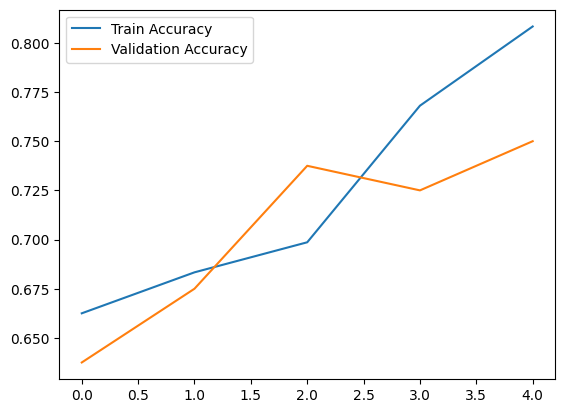

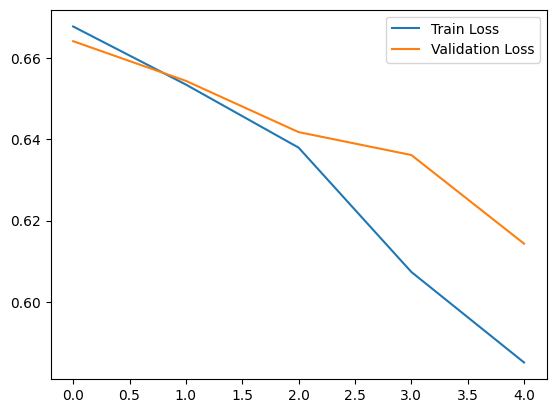

In [37]:
import matplotlib.pyplot as plt

plt.plot(normal.history['accuracy'], label='Train Accuracy')
plt.plot(normal.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(normal.history['loss'], label='Train Loss')
plt.plot(normal.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()
